<a href="https://colab.research.google.com/github/jacqhorizon/csb410_final/blob/gan_v3/notebooks/3_gan_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GAN Segmentation on UECFoodPix
This notebook trains a pix2pix-style GAN to predict a binary food segmentation mask.

Outputs saved to Google Drive:
- Saved generator model (`gan_generator.keras`)
- Grid visualization examples (GT (Ground Truth) vs GAN)
- IoU and Dice histogram plots


## 1) Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2) Paths and dataset sanity checks

In [ ]:
import os
from pathlib import Path

# Set the root for GAN dataset
DATASET_ROOT = "/content/drive/MyDrive/datasets/UECFOODPIXCOMPLETE/data/UECFoodPIXCOMPLETE"
# Add "img" or "mask" to train file paths
TRAIN_IMG_DIR  = os.path.join(DATASET_ROOT, "train", "img")
TRAIN_MASK_DIR = os.path.join(DATASET_ROOT, "train", "mask")
# Add "img" or "mask" to test file paths
TEST_IMG_DIR   = os.path.join(DATASET_ROOT, "test", "img")
TEST_MASK_DIR  = os.path.join(DATASET_ROOT, "test", "mask")
# Print the directories
print("TRAIN_IMG_DIR :", TRAIN_IMG_DIR)
print("TRAIN_MASK_DIR:", TRAIN_MASK_DIR)
print("TEST_IMG_DIR  :", TEST_IMG_DIR)
print("TEST_MASK_DIR :", TEST_MASK_DIR)

# Check that each directory was made
for p in [TRAIN_IMG_DIR, TRAIN_MASK_DIR, TEST_IMG_DIR, TEST_MASK_DIR]:
    if not os.path.isdir(p):
        raise FileNotFoundError(f"Missing directory: {p}")
# Count the number of files (.jpg or .png) in a directory
def count_files(dir_path):
    return len([f for f in os.listdir(dir_path) if f.lower().endswith(('.jpg', '.png'))])
# Check the file counts for each directory
print("\nCounts:")
print(" train/img :", count_files(TRAIN_IMG_DIR))
print(" train/mask:", count_files(TRAIN_MASK_DIR))
print(" test/img  :", count_files(TEST_IMG_DIR))
print(" test/mask :", count_files(TEST_MASK_DIR))
# Print example file names
print("\nExample filenames:")
print(" train/img :", sorted(os.listdir(TRAIN_IMG_DIR))[:5])
print(" train/mask:", sorted(os.listdir(TRAIN_MASK_DIR))[:5])


TRAIN_IMG_DIR : /content/drive/MyDrive/datasets/UECFOODPIXCOMPLETE/data/UECFoodPIXCOMPLETE/train/img
TRAIN_MASK_DIR: /content/drive/MyDrive/datasets/UECFOODPIXCOMPLETE/data/UECFoodPIXCOMPLETE/train/mask
TEST_IMG_DIR  : /content/drive/MyDrive/datasets/UECFOODPIXCOMPLETE/data/UECFoodPIXCOMPLETE/test/img
TEST_MASK_DIR : /content/drive/MyDrive/datasets/UECFOODPIXCOMPLETE/data/UECFoodPIXCOMPLETE/test/mask

Counts:
 train/img : 9000
 train/mask: 9000
 test/img  : 1000
 test/mask : 1000

Example filenames:
 train/img : ['1.jpg', '10.jpg', '100.jpg', '1000.jpg', '1001.jpg']
 train/mask: ['1.png', '10.png', '100.png', '1000.png', '1001.png']


## 3) TensorFlow setup and GPU check

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 4) Functions - load and preprocess image mask pairs, build dataset

In [ ]:
def load_image_mask(img_path, mask_path, img_size=256):
    """
    Loads an image and its corresponding segmentation mask from disk,
    resizes them to a fixed square size, and returns them as normalized
    TensorFlow tensors suitable for binary segmentation.

    Args:
        img_path (str or tf.Tensor): Path to the image file.
        mask_path (str or tf.Tensor): Path to the corresponding mask file.
        img_size (int, optional): Target height and width of the image and mask.
            Defaults to 256.

    Returns:
        tuple:
            img (tf.Tensor): Float32 tensor of shape
                (img_size, img_size, 3) with values in [0.0, 1.0].
                  Shape is (height, width, channels)
            mask (tf.Tensor): Float32 tensor of shape
                (img_size, img_size, 1) with binary values {0.0, 1.0}.
    """
    # Load image
    img = tf.io.read_file(img_path) # raw bytes
    # Decode raw bytes into an image tensor, 3 (RGB) color channels
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    # Resize to fixed size img_size x img_size
    img = tf.image.resize(img, (img_size, img_size))
    # Convert pixel data to float, rescale from 0.0 to 1.0
    img = tf.cast(img, tf.float32) / 255.0

    # Load mask
    mask = tf.io.read_file(mask_path) # raw bytes
    # Decode raw bytes into an image tensor, 1 (grayscale) color channel
    mask = tf.image.decode_image(mask, channels=1, expand_animations=False)
    # Resize to fixed size img_size x img_size
    mask = tf.image.resize(mask, (img_size, img_size), method="nearest")
    # method="nearest" for nearest neighbor interpolation
    # Convert pixel data to float
    mask = tf.cast(mask, tf.float32)

    # Binary segmentation: food vs background
    mask = tf.where(mask > 0, 1.0, 0.0)

    return img, mask


def build_uecfoodpix_dataset(
    img_dir,
    mask_dir,
    batch_size=8,
    img_size=256,
    shuffle=True
):
    """
    Builds a TensorFlow dataset from UECFoodPixComplete segmentation dataset
    image and mask directories. Pairs image with corresponding binary mask
    and applies preprocessing, batching, and prefetching.

    Assumes a one-to-one correspondence between image files
    and mask files based on sorted filename order.

    The resulting tf.data.Dataset is batches of '(image, mask)' tensors.

    Args:
        img_dir (str): Path to the directory containing image files.
        mask_dir (str): Path to the directory containing mask files.
        batch_size (int, optional): Number of samples per batch. Defaults to 8.
        img_size (int, optional): Target height and width of the images.
            Defaults to 256.
        shuffle (bool, optional): Whether to shuffle the dataset. Defaults to True.

    Returns:
        tf.data.Dataset


    """
    # Create a list of image file paths and sort lexicographically
    img_files = sorted([
        # For each image file, join the directory path with the filename
        os.path.join(img_dir, f)
        for f in os.listdir(img_dir)
        if f.lower().endswith((".jpg", ".png"))
    ])
    # Create a list of mask file paths and sort lexicographically
    mask_files = sorted([
        # For each mask file, join the directory path with the filename
        os.path.join(mask_dir, f)
        for f in os.listdir(mask_dir)
        if f.lower().endswith((".jpg", ".png"))
    ])

    # Dataset validation checks and error messages
    if len(img_files) == 0:
        raise RuntimeError(f"No images found in {img_dir}")
    if len(mask_files) == 0:
        raise RuntimeError(f"No masks found in {mask_dir}")
    if len(img_files) != len(mask_files):
        raise RuntimeError(f"Image/mask count mismatch: {len(img_files)} vs {len(mask_files)}")

    # Create the tensorflow dataset from two lists of files
    ds = tf.data.Dataset.from_tensor_slices((img_files, mask_files))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(img_files), reshuffle_each_iteration=True)

    # Transform each dataset element with load_image_mask function
    ds = ds.map(
        lambda i, m: load_image_mask(i, m, img_size),
        # determine how many parallel workers
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # Group (image, mask) pairs into batches
    ds = ds.batch(batch_size)
    # Preload future batches while the model is training
    ds = ds.prefetch(tf.data.AUTOTUNE)
    # Return dataset ready for model.fit(ds)
    return ds


## 5) Build train/test datasets

In [ ]:
# Create the training dataset
train_ds = build_uecfoodpix_dataset(
    TRAIN_IMG_DIR,
    TRAIN_MASK_DIR,
    batch_size=8,
    shuffle=True
)
# Create the test dataset
test_ds = build_uecfoodpix_dataset(
    TEST_IMG_DIR,
    TEST_MASK_DIR,
    batch_size=8,
    shuffle=False
)

# Verify shapes, min and max pixel values, mask unique values
images, masks = next(iter(train_ds))
print("images:", images.shape, images.dtype, "min/max:", float(tf.reduce_min(images)), float(tf.reduce_max(images)))
print("masks :", masks.shape, masks.dtype,  "unique:", np.unique(masks.numpy())[:10])


images: (8, 256, 256, 3) <dtype: 'float32'> min/max: 0.0 1.0
masks : (8, 256, 256, 1) <dtype: 'float32'> unique: [0. 1.]


## 6) Generator (U-Net) and Discriminator (PatchGAN)
A 4x4 kernel with stride=2 is used for GANs because the larger field is better for downsampling and upsampling, and stride 2 is the standard pattern. Batch normalization dampens sudden shifts and keeps gradients in a normal range, since the generator/discriminator are constantly changing and can explore or vanish. It makes learning faster and more consistent. Leaky relu applies a scalar (the "slope", in this case 0.2) to negative values instead of making them 0, which prevents dead neurons with gradient 0. For layer sizes I just followed the simple layout ChatGPT suggested and I did not play around with other model architectures due to my goal being working MVP and incorporation with group code.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

def build_generator(img_size=256):
    inputs = layers.Input(shape=(img_size, img_size, 3))

    # Downsampling block (Encoder)
    # x = input tensor, f = number of convolutional filters
    # 4 = kernel size 4x4 (common for GANs), strides=2 halves height and width
    # (H, W) → (H/2, W/2)
    def down(x, f):
        x = layers.Conv2D(f, 4, strides=2, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.LeakyReLU(0.2)(x) # slope = 0.2, prevents dead neurons
        return x # downsampled

    # Upsampling block (Decoder)
    def up(x, skip, f):
        x = layers.Conv2DTranspose(f, 4, strides=2, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        return layers.Concatenate()([x, skip])

    # Downsample
    d1 = down(inputs, 64)     # 128
    d2 = down(d1, 128)        # 64
    d3 = down(d2, 256)        # 32
    d4 = down(d3, 512)        # 16
    # Bottleneck
    b  = layers.Conv2D(512, 4, strides=2, padding="same")(d4)  # 8
    b  = layers.ReLU()(b)
    # Upsample
    u1 = up(b,  d4, 512)
    u2 = up(u1, d3, 256)
    u3 = up(u2, d2, 128)
    u4 = up(u3, d1, 64)

    out = layers.Conv2DTranspose(1, 4, strides=2, padding="same")(u4)
    out = layers.Activation("sigmoid")(out)

    return Model(inputs, out, name="generator")

In [ ]:
def build_discriminator(img_size=256):
    img = layers.Input(shape=(img_size, img_size, 3))
    mask = layers.Input(shape=(img_size, img_size, 1))
    x = layers.Concatenate()([img, mask])

    def block(x, f, s=2):
        x = layers.Conv2D(f, 4, strides=s, padding="same")(x)
        x = layers.LeakyReLU(0.2)(x)
        return x

    x = block(x, 64)
    x = block(x, 128)
    x = block(x, 256)
    x = layers.Conv2D(1, 4, padding="same")(x)

    return Model([img, mask], x, name="discriminator")

## 7) Losses, optimizers, and training step

In [ ]:
bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)

LAMBDA_L1 = 100.0

def generator_loss(d_fake, y_true, y_pred):
    adv = bce(tf.ones_like(d_fake), d_fake)
    l1  = tf.reduce_mean(tf.abs(y_true - y_pred))
    return adv + LAMBDA_L1 * l1, adv, l1

def discriminator_loss(d_real, d_fake):
    real = bce(tf.ones_like(d_real), d_real)
    fake = bce(tf.zeros_like(d_fake), d_fake)
    return real + fake

generator = build_generator()
discriminator = build_discriminator()

gen_opt  = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
disc_opt = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

In [ ]:
@tf.function
def train_step(images, masks):
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        pred_masks = generator(images, training=True)

        d_real = discriminator([images, masks], training=True)
        d_fake = discriminator([images, pred_masks], training=True)

        g_total, g_adv, g_l1 = generator_loss(d_fake, masks, pred_masks)
        d_total = discriminator_loss(d_real, d_fake)

    gen_grads  = gen_tape.gradient(g_total, generator.trainable_variables)
    disc_grads = disc_tape.gradient(d_total, discriminator.trainable_variables)

    gen_opt.apply_gradients(zip(gen_grads, generator.trainable_variables))
    disc_opt.apply_gradients(zip(disc_grads, discriminator.trainable_variables))

    return g_total, g_adv, g_l1, d_total

## 8) Training loop

In [ ]:
EPOCHS = 5

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    for step, (img, msk) in enumerate(train_ds.take(200)):  # limit for speed
        g_tot, g_adv, g_l1, d_tot = train_step(img, msk)

        if step % 50 == 0:
            print(f"step {step}: "
                  f"G={g_tot:.2f} (adv={g_adv:.2f}, l1={g_l1:.2f}) "
                  f"D={d_tot:.2f}")


Epoch 1/5
step 0: G=50.67 (adv=0.71, l1=0.50) D=1.39
step 50: G=25.11 (adv=0.94, l1=0.24) D=1.04
step 100: G=20.54 (adv=1.41, l1=0.19) D=0.86
step 150: G=22.07 (adv=1.57, l1=0.20) D=0.94

Epoch 2/5
step 0: G=12.69 (adv=1.21, l1=0.11) D=1.21
step 50: G=18.36 (adv=1.31, l1=0.17) D=1.14
step 100: G=16.96 (adv=1.09, l1=0.16) D=1.22
step 150: G=13.85 (adv=0.47, l1=0.13) D=1.37

Epoch 3/5
step 0: G=18.46 (adv=0.61, l1=0.18) D=1.26
step 50: G=18.97 (adv=0.82, l1=0.18) D=1.19
step 100: G=19.66 (adv=0.82, l1=0.19) D=1.23
step 150: G=16.84 (adv=0.77, l1=0.16) D=1.24

Epoch 4/5
step 0: G=14.64 (adv=0.84, l1=0.14) D=1.22
step 50: G=23.15 (adv=1.05, l1=0.22) D=1.28
step 100: G=14.81 (adv=0.79, l1=0.14) D=1.21
step 150: G=11.93 (adv=0.86, l1=0.11) D=1.28

Epoch 5/5
step 0: G=19.54 (adv=1.12, l1=0.18) D=1.20
step 50: G=15.45 (adv=0.76, l1=0.15) D=1.31
step 100: G=15.89 (adv=0.85, l1=0.15) D=1.25
step 150: G=10.93 (adv=0.93, l1=0.10) D=1.24


## 9) Evaluate on test set (IoU & Dice)

In [ ]:
def iou_score(y_true, y_pred, thresh=0.5):
    y_pred = tf.cast(y_pred > thresh, tf.float32)
    inter = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - inter
    return inter / (union + 1e-7)

def dice_score(y_true, y_pred, thresh=0.5):
    y_pred = tf.cast(y_pred > thresh, tf.float32)
    inter = tf.reduce_sum(y_true * y_pred)
    return (2 * inter) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + 1e-7)

ious, dices = [], []

for images, masks in test_ds.take(20):
    preds = generator(images, training=False)
    for i in range(images.shape[0]):
        ious.append(iou_score(masks[i], preds[i]).numpy())
        dices.append(dice_score(masks[i], preds[i]).numpy())

print("Mean IoU:", sum(ious)/len(ious))
print("Mean Dice:", sum(dices)/len(dices))

Mean IoU: 0.76437193
Mean Dice: 0.8473216


## 10) Save generator model to Drive

In [ ]:
import os

MODEL_DIR = "/content/drive/MyDrive/models"
os.makedirs(MODEL_DIR, exist_ok=True)

SAVE_PATH = "/content/drive/MyDrive/models/gan_generator.keras"
generator.save(SAVE_PATH)

print("Saved to:", SAVE_PATH)

Saved to: /content/drive/MyDrive/models/gan_generator.keras


## 11) Visualize grid of test results (and save)
Saved image is a grid of: **Image | GT mask | GAN mask**.

In [ ]:
# Where to save report-friendly artifacts
RESULTS_DIR = "/content/drive/MyDrive/gan_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

GRID_SAVE_PATH = os.path.join(RESULTS_DIR, "gan_test_grid.png")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_batch(generator, dataset, n=6, thresh=0.5, save_path=None):
    images, masks = next(iter(dataset))
    preds = generator(images, training=False)
    preds_bin = (preds.numpy() > thresh).astype(np.float32)

    n = min(n, images.shape[0])
    plt.figure(figsize=(12, 2*n))

    for i in range(n):
        # image
        plt.subplot(n, 3, 3*i + 1)
        plt.imshow(images[i])
        plt.title("Image")
        plt.axis("off")

        # GT
        plt.subplot(n, 3, 3*i + 2)
        plt.imshow(masks[i,...,0], cmap="gray")
        plt.title("GT mask")
        plt.axis("off")

        # Pred
        plt.subplot(n, 3, 3*i + 3)
        plt.imshow(preds_bin[i,...,0], cmap="gray")
        plt.title("GAN mask")
        plt.axis("off")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

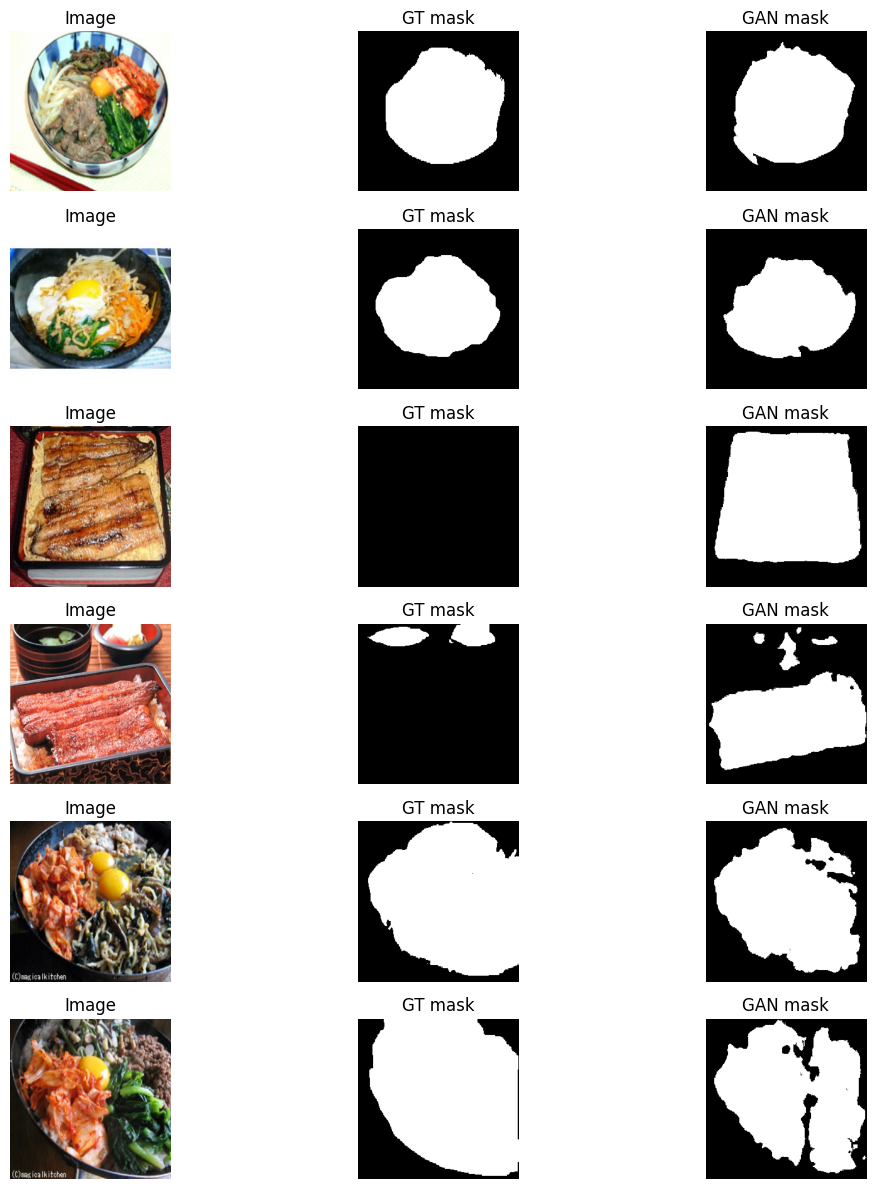

Saved grid to: /content/drive/MyDrive/gan_results/gan_test_grid.png


In [ ]:
visualize_batch(generator, test_ds, n=6, save_path=GRID_SAVE_PATH)
print("Saved grid to:", GRID_SAVE_PATH)


## 12) IoU & Dice distributions (and save)
These plots are saved so you can drop them into a report.

IoU  mean/std: 0.7643719911575317 0.19627875089645386
Dice mean/std: 0.8473215103149414 0.17605182528495789


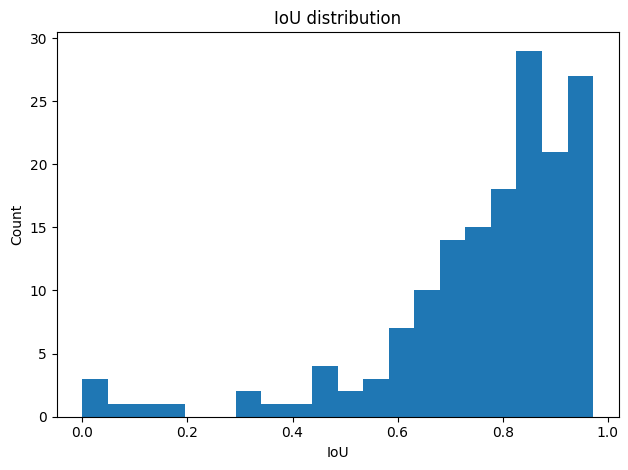

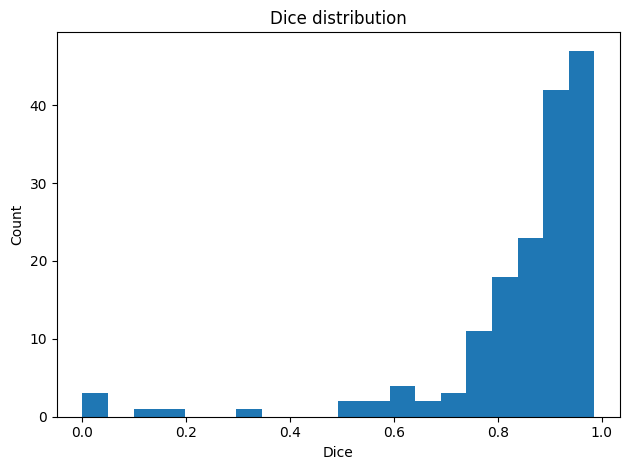

Saved IoU hist to : /content/drive/MyDrive/gan_results/iou_distribution.png
Saved Dice hist to: /content/drive/MyDrive/gan_results/dice_distribution.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

ious = np.array(ious)
dices = np.array(dices)

print("IoU  mean/std:", float(ious.mean()), float(ious.std()))
print("Dice mean/std:", float(dices.mean()), float(dices.std()))

IOU_HIST_PATH  = os.path.join(RESULTS_DIR, "iou_distribution.png")
DICE_HIST_PATH = os.path.join(RESULTS_DIR, "dice_distribution.png")

plt.figure()
plt.hist(ious, bins=20)
plt.title("IoU distribution")
plt.xlabel("IoU")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(IOU_HIST_PATH, dpi=200, bbox_inches="tight")
plt.show()

plt.figure()
plt.hist(dices, bins=20)
plt.title("Dice distribution")
plt.xlabel("Dice")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(DICE_HIST_PATH, dpi=200, bbox_inches="tight")
plt.show()

print("Saved IoU hist to :", IOU_HIST_PATH)
print("Saved Dice hist to:", DICE_HIST_PATH)
